In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from openradar.mmwave.dataloader.adc import DCA1000
from openradar.mmwave.dsp.range_processing import range_processing
from openradar.mmwave.dsp.doppler_processing import doppler_processing
from openradar.mmwave.dsp.utils import Window
from scipy.signal import savgol_filter

In [1]:

DATA_PATH="../../data/Hand/adc_data_2026-06-09_16-25-14_handMov.npy"
numFrames = 600
numADCSamples = 256
numTxAntennas = 3
numRxAntennas = 4
numLoopsPerFrame = 182
numChirpsPerFrame = numTxAntennas * numLoopsPerFrame

In [3]:

def iterative_range_bins_detection(rangeResult, min_bin=10, max_bin=None):
    rangeResult = np.transpose(np.stack([rangeResult[0::3], rangeResult[1::3], rangeResult[2::3]], axis=1),axes=(1,2,0,3))
    range_result_absnormal_split=[]
    
    for i in range(numTxAntennas):
        for j in range(numRxAntennas):
            r_r=np.abs(rangeResult[i][j])
            
            r_r[:, :min_bin] = 0
            if max_bin is not None:
                r_r[:, max_bin:] = 0 
                
            min_val = np.min(r_r)
            max_val = np.max(r_r)
            
            if max_val == min_val: 
                r_r_normalise = np.zeros_like(r_r)
            else:
                r_r_normalise = (r_r - min_val) / (max_val - min_val) * (1000 - 0) + 0
                
            range_result_absnormal_split.append(r_r_normalise)
    
    range_abs_combined_nparray=np.zeros((numLoopsPerFrame,numADCSamples))
    for ele in range_result_absnormal_split:
        range_abs_combined_nparray+=ele
    range_abs_combined_nparray/=(numTxAntennas*numRxAntennas)
    
    range_abs_combined_nparray_collapsed=np.sum(range_abs_combined_nparray,axis=0)/numLoopsPerFrame
    peaks_min_intensity_threshold = np.argsort(range_abs_combined_nparray_collapsed)[::-1][:max_bin-min_bin]
    max_range_index=np.argmax(range_abs_combined_nparray_collapsed)
    
    return max_range_index, peaks_min_intensity_threshold, rangeResult

In [4]:
def get_averaged_phase(rangeResult, target_bin):
    all_phases = []
    for tx in range(numTxAntennas):
        for rx in range(numRxAntennas):
            unwrapped_phase = get_phase_antennawise(rangeResult[tx][rx], target_bin)
            all_phases.append(unwrapped_phase)
    all_phases = np.array(all_phases)
    avg_phase = np.mean(all_phases, axis=0)
    
    return avg_phase

def get_phase(r,i):
        if r==0 and i==0:
            phase = 0.0
        elif r==0:
            if i>0:
                phase=np.pi/2
            else :
                phase=3*np.pi/2
        elif r>0:
            if i>=0:
                phase=np.arctan(i/r)
            if i<0:
                phase=2*np.pi - np.arctan(-i/r)
        elif r<0:
            if i>=0:
                phase=np.pi - np.arctan(-i/r)
            else:
                phase=np.pi + np.arctan(i/r)
        return phase

def get_phase_antennawise(range_FFT_,peak):
    phase_per_antenna=[]
    vel_peak=[]
    for k in range(0,numLoopsPerFrame):
        r = range_FFT_[k][peak].real
        i = range_FFT_[k][peak].imag
        phase=get_phase(r,i)
        phase_per_antenna.append(phase)
    phase_cur_frame=phase_unwrapping(len(phase_per_antenna),phase_per_antenna)
    return phase_cur_frame

def phase_unwrapping(phase_len,phase_cur_frame):
    i=1
    new_signal_phase = phase_cur_frame
    for k,ele in enumerate(new_signal_phase):
        if k==len(new_signal_phase)-1:
            continue
        if new_signal_phase[k+1] - new_signal_phase[k] > 1.5*np.pi:
            new_signal_phase[k+1:] = new_signal_phase[k+1:] - 2*np.pi*np.ones(len(new_signal_phase[k+1:]))
    return np.array(new_signal_phase)  

[19 18 14 15  9  8 13 16 17 12 10  7 11  5  6]
Set up basic absolute phase array
Processing frames 50 to 99...
Phase extraction complete. Calculating Acceleration...


NameError: name 'save_directory' is not defined

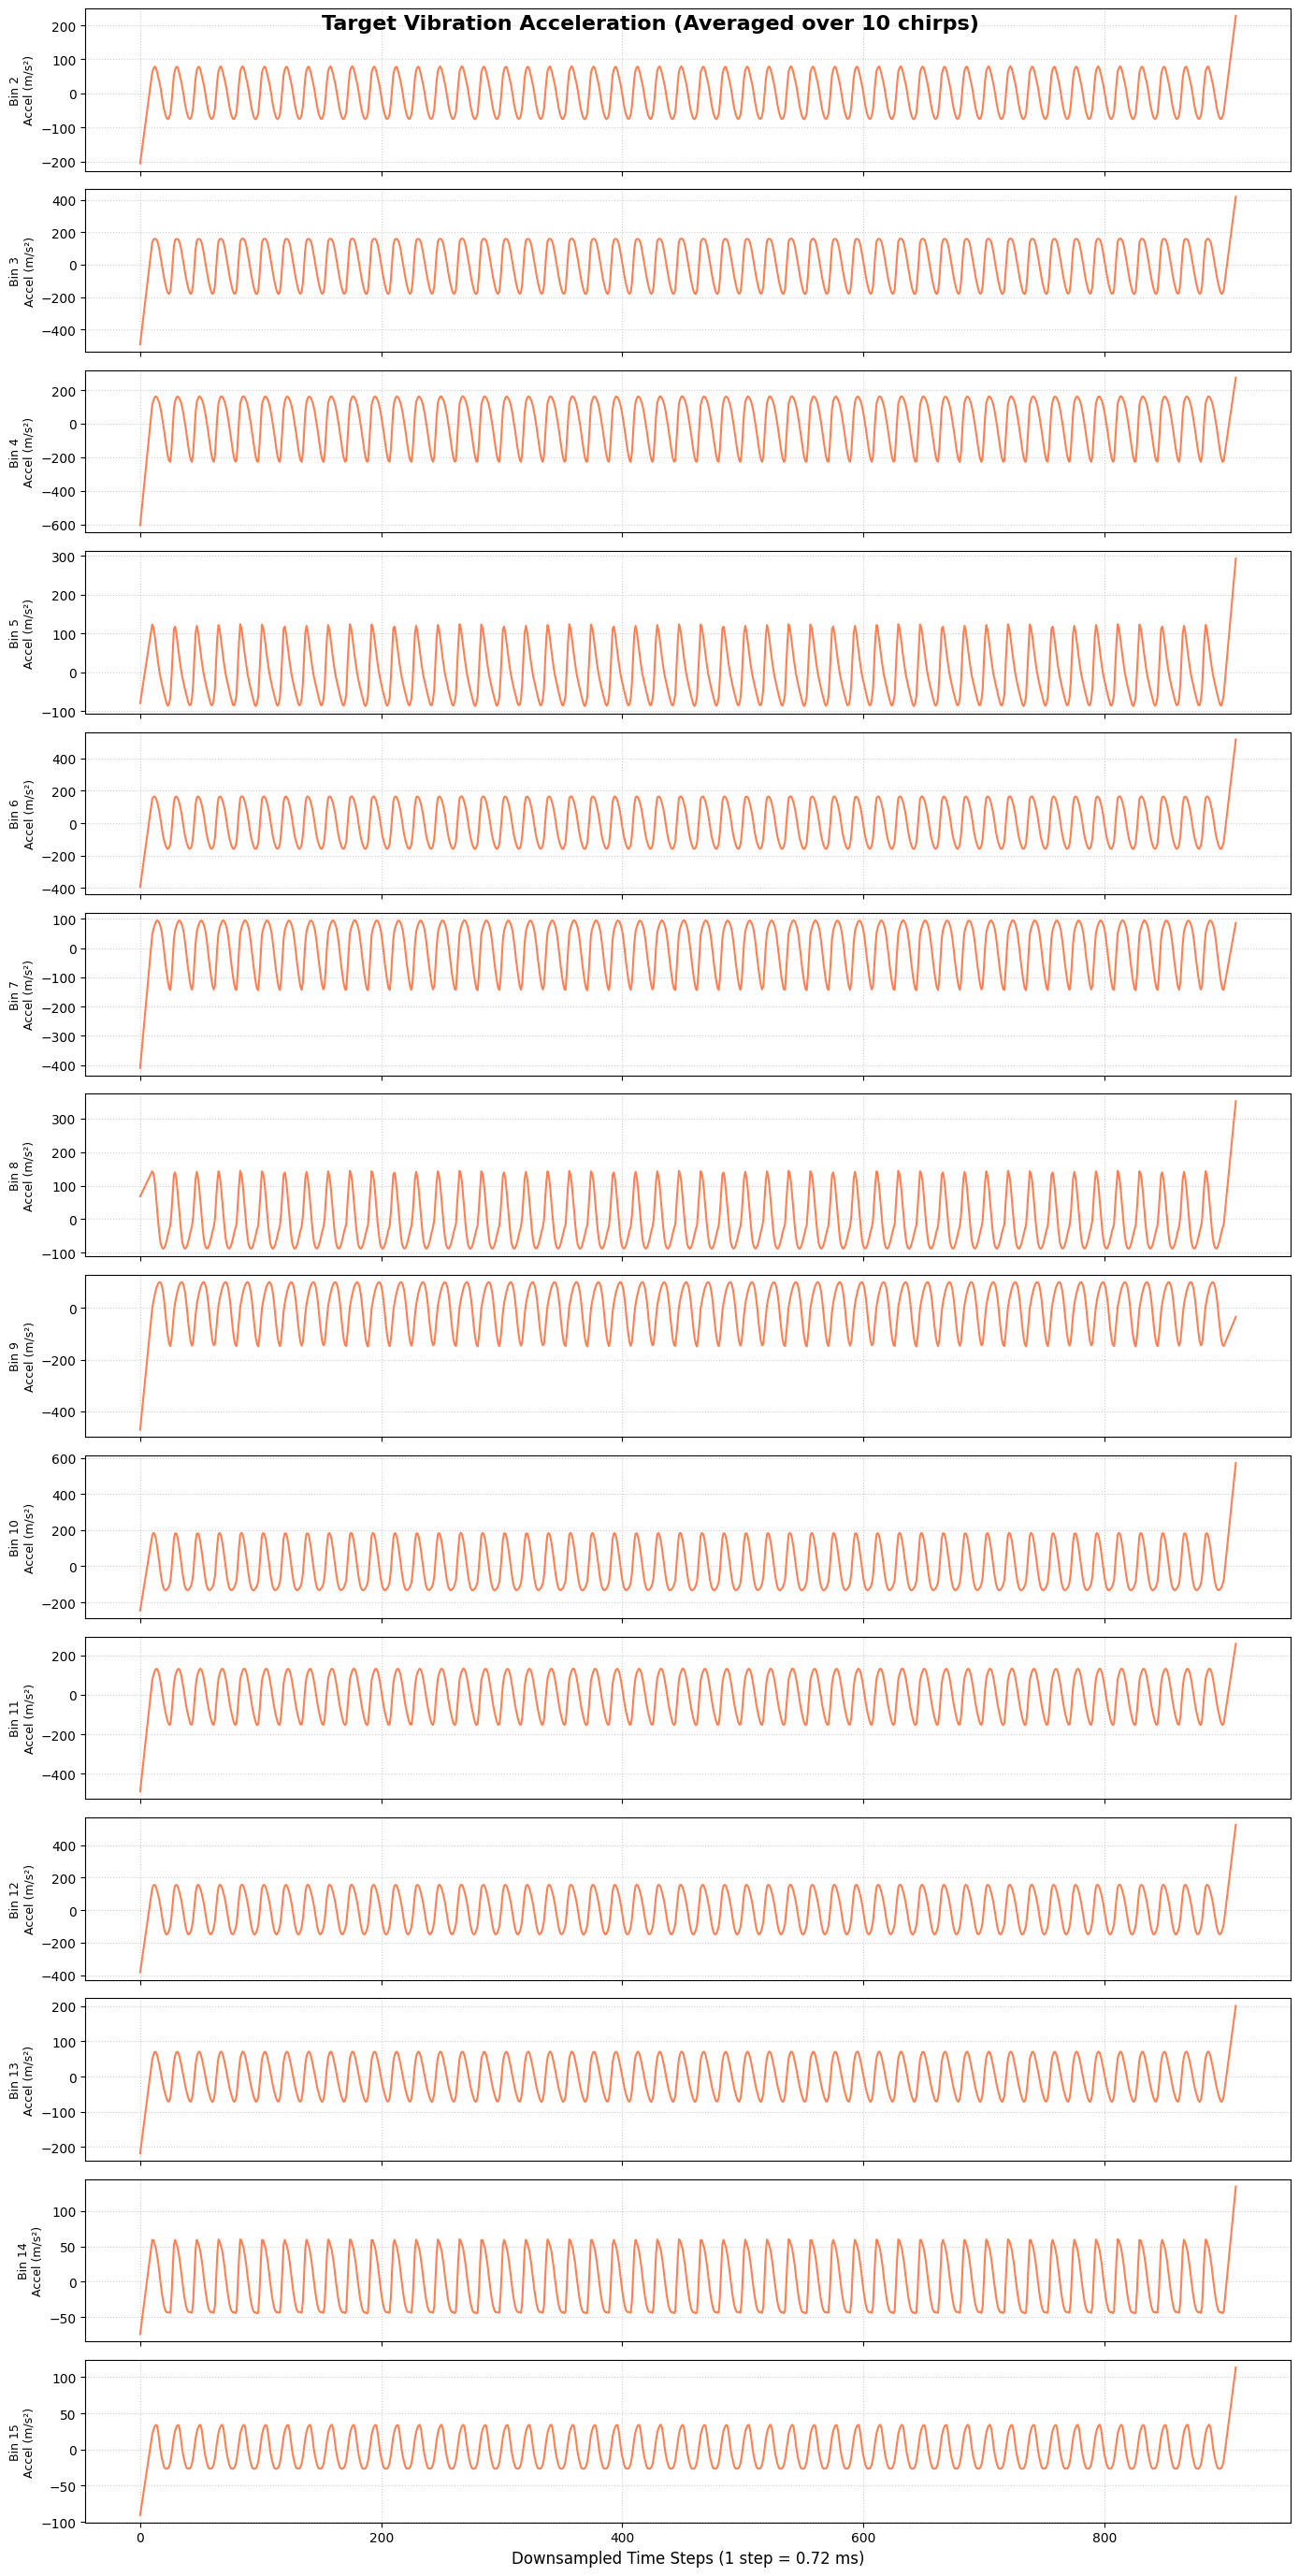

In [8]:
if __name__ == "__main__":
    loaded_adc_data = np.load(DATA_PATH)
    start_frame = 50
    num_frames = 50
    

    Tc = 72e-6       
    downsample_factor = 10 
    new_dt = Tc * downsample_factor 
    wavelength = 3e8 / 77e9          # ~3.9mm for 77GHz radar
    
    # Setting up starter frame
    starter_adc_data = loaded_adc_data
    starter_frame = starter_adc_data[49:50]
    adc_data = np.apply_along_axis(DCA1000.organize, 1, starter_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
    radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
    
    min_b = 5
    max_b = 20
    _, range_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
    print(range_bins)

    target_bins = [i for i in range(range_bins[4]-7, range_bins[4]+7)]
    
    # CHANGE 1: Accumulate ABSOLUTE phase, not differences
    accumulated_phase = {bin_idx: [] for bin_idx in target_bins}
    print("Set up basic absolute phase array")

    print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")
    for f in range(start_frame, start_frame + num_frames):
        current_frame = loaded_adc_data[f-1 : f]
        adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame, num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
        radar_cube = range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)
        
        for target_bin in target_bins:
            avg_phase = get_averaged_phase(rangeResult, target_bin)
            # Ensure the phase is unwrapped so we track continuous displacement!
            unwrapped_phase = np.unwrap(avg_phase) 
            accumulated_phase[target_bin].extend(unwrapped_phase)

    print("Phase extraction complete. Calculating Acceleration...")
    
    fig, axes = plt.subplots(len(target_bins), 1, figsize=(14, 2 * len(target_bins)), sharex=True)
    if len(target_bins) == 1: axes = [axes] # Handle single bin scenario safely
    
    fig.suptitle(f"Target Vibration Acceleration (Averaged over {downsample_factor} chirps)", fontsize=16, fontweight='bold')

    for idx, target_bin in enumerate(target_bins):
        phase_array = np.array(accumulated_phase[target_bin])
        remainder = len(phase_array) % downsample_factor
        if remainder != 0:
            phase_array = phase_array[:-remainder]
            
        downsampled_phase = np.mean(phase_array.reshape(-1, downsample_factor), axis=1)
        
        displacement_m = (wavelength * downsampled_phase) / (4 * np.pi)
        window_length = 21 
        if len(displacement_m) < window_length:
            window_length = len(displacement_m) - 1 if len(displacement_m) % 2 == 0 else len(displacement_m) - 2
            if window_length < 3: window_length = 3
            
        acceleration = savgol_filter(
            displacement_m, 
            window_length=window_length, 
            polyorder=3, 
            deriv=2, 
            delta=new_dt  # Critical: Use the new time gap to scale the derivative correctly
        )
        
        # Step D: Plotting
        ax = axes[idx]
        ax.plot(acceleration, color='coral', linewidth=1.5)
        ax.set_ylabel(f"Bin {target_bin}\nAccel (m/s²)", fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.6)

    axes[-1].set_xlabel(f"Downsampled Time Steps (1 step = {new_dt*1000:.2f} ms)", fontsize=12)
    plt.tight_layout()
    
    plt.savefig(os.path.join(save_directory, "Vibration_Acceleration.png"))
    plt.show()